In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(42)

In [2]:
X, y = make_moons(
    n_samples=6000,
    noise=0.25,
    random_state=42
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Klasser:", np.unique(y))

X shape: (6000, 2)
y shape: (6000,)
Klasser: [0 1]


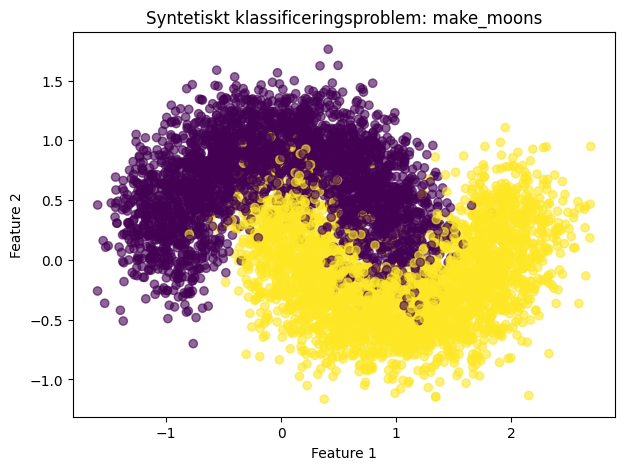

In [3]:
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.6)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Syntetiskt klassificeringsproblem: make_moons")
plt.show()

In [4]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=42,
    stratify=y_train_full
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (3600, 2)
Validation: (1200, 2)
Test: (1200, 2)


In [5]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(X_train)
x_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [6]:
def build_model(learning_rate=0.001):
    """
    Bygger och kompilerar en enkel neural nätverksmodell

    learning_rate:
        Styr hur stora steg optimizer tar när vikterna uppdateras.
    """

    model = keras.Sequential([
        layers.Input(shape=(2, )),

        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),

        layers.Dense(1, activation="sigmoid"),
    ])
    
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
       optimizer=optimizer,
       loss="binary_crossentropy",
       metrics=["accuracy"]
    )

    return model

In [7]:
def plot_history(history, title="Träningskurvor"):
    """
    Plottar loss och accuracy för både träning och validation.

    history:
        Objektet som returneras från model.fit().
        Den innehåller mätvärden för varje epok

    title:
        Rubrik som gör det lättare att se vliket eperiment grafen hör till.
    """

    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(history_df["loss"], label="Training loss")
    plt.plot(history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epok")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history_df["accuracy"], label="Training accuracy")
    plt.plot(history_df["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epok")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.suptitle(title)
    plt.show()

In [8]:
def run_experiment(name, epochs=30, batch_size=32, learning_rate=0.001, verbose=0):
    """
    Bygger, tränar och utvärderar en modell med givna inställningar.

    name:
        Namn på experimentet. Används i utskrifter och grafer.

    epochs:
        Hur många gånger modellen ska gå igenom träningsdatan.

    batch_size:
        Hur många datapunkter modeller använder innan vikterna uppdateras.

    learning_rate:
        Hur stora steg optimizer tar när vikterna uppdateras.

    verbose:
        Styr hur mycket Keras skriver ut under träningen.
        0 = tyst, 1 = progressbar
    """

    print(f"\nKör experiment: {name}")
    print(f"epochs={epochs}, batch_size={batch_size}, learning_rate={learning_rate}")

    model = build_model(learning_rate=learning_rate)

    history = model.fit(
        x_train_scaled,
        y_train,
        validation_data=(x_val_scaled, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose
    )

    test_loss, test_accuracy = model.evaluate(
        X_test_scaled,
        y_test,
        verbose=0
    )

    plot_history(history, title=name)

    result = {
        "experiment": name,
        "epochs": epochs,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "test_loss": test_loss,
        "test_accuraccy": test_accuracy
    }

    return model, history, result


Kör experiment: Baseline: 30 epoker, batch size 32, learning rate 0.001
epochs=30, batch_size=32, learning_rate=0.001


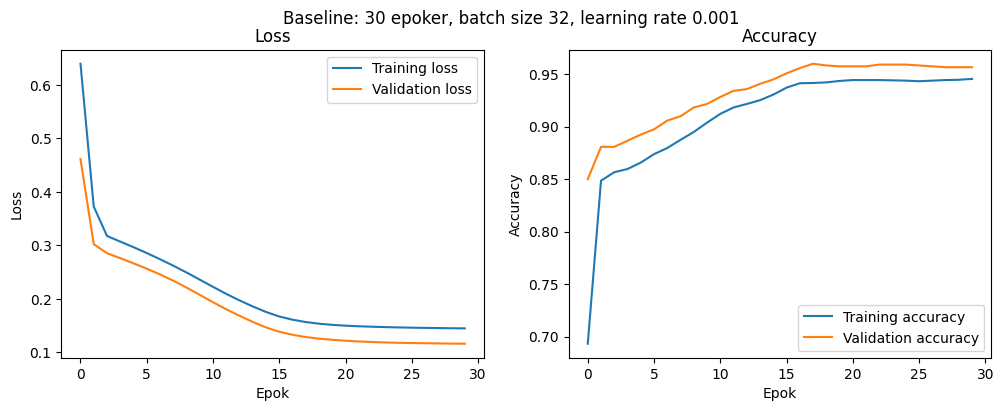

In [9]:
results = []

baseline_model, baseline_history, baseline_result = run_experiment(
    name="Baseline: 30 epoker, batch size 32, learning rate 0.001",
    epochs=30,
    batch_size=32,
    learning_rate=0.001,
    verbose=0
)

results.append(baseline_result)


Kör experiment: Få epoker: 5 epoker
epochs=5, batch_size=32, learning_rate=0.001


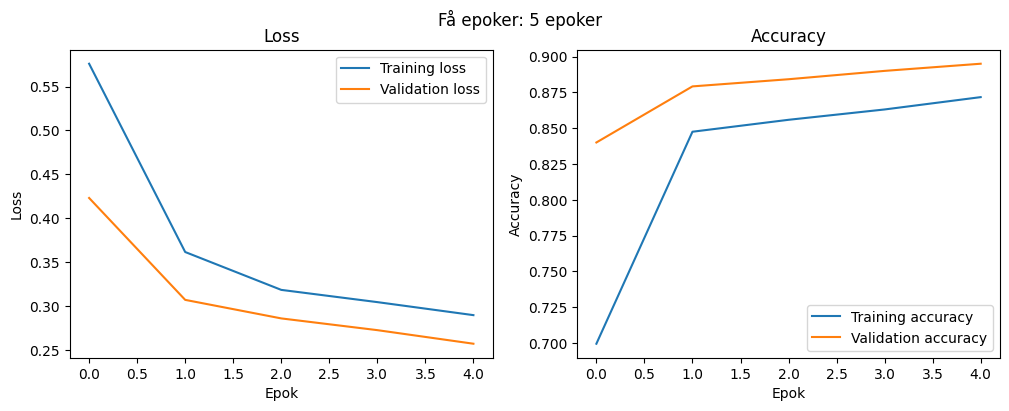

In [10]:
few_epochs_model, few_epochs_history, few_epochs_result = run_experiment(
    name="Få epoker: 5 epoker",
    epochs=5,
    batch_size=32,
    learning_rate=0.001,
    verbose=0
)

results.append(few_epochs_result)


Kör experiment: Många epoker: 100 epoker
epochs=100, batch_size=32, learning_rate=0.001


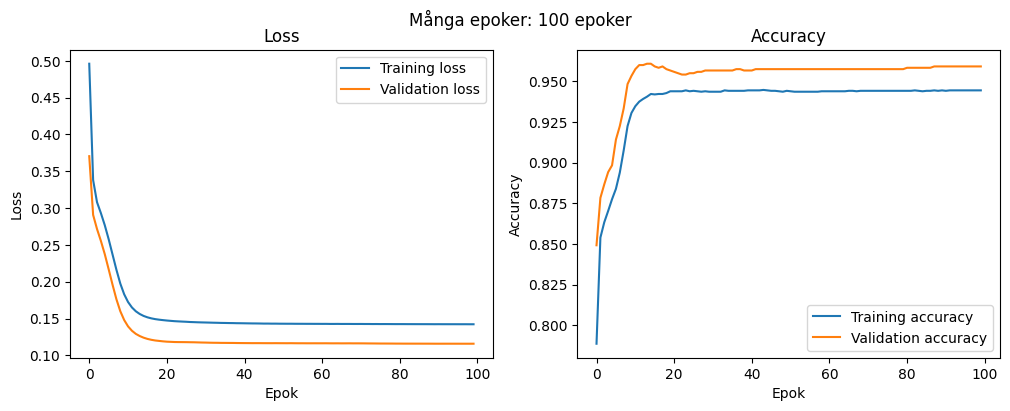

In [11]:
many_epochs_model, many_epochs_history, many_epochs_result = run_experiment(
    name="Många epoker: 100 epoker",
    epochs=100,
    batch_size=32,
    learning_rate=0.001,
    verbose=0
)

results.append(many_epochs_result)


Kör experiment: Låg learning rate: 0.0001
epochs=30, batch_size=32, learning_rate=0.0001


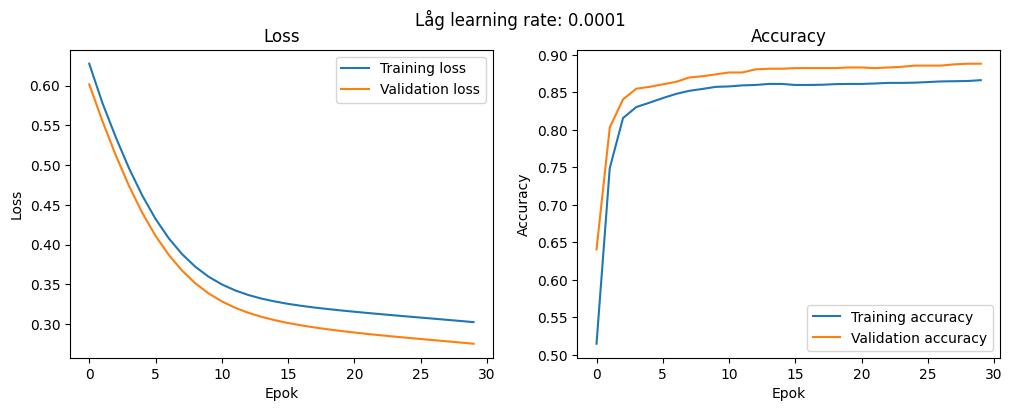

In [12]:
low_lr_model, low_lr_history, low_lr_result = run_experiment(
    name="Låg learning rate: 0.0001",
    epochs=30,
    batch_size=32,
    learning_rate=0.0001,
    verbose=0
)

results.append(low_lr_result)


Kör experiment: Hög learning rate: 0.1
epochs=30, batch_size=32, learning_rate=0.1


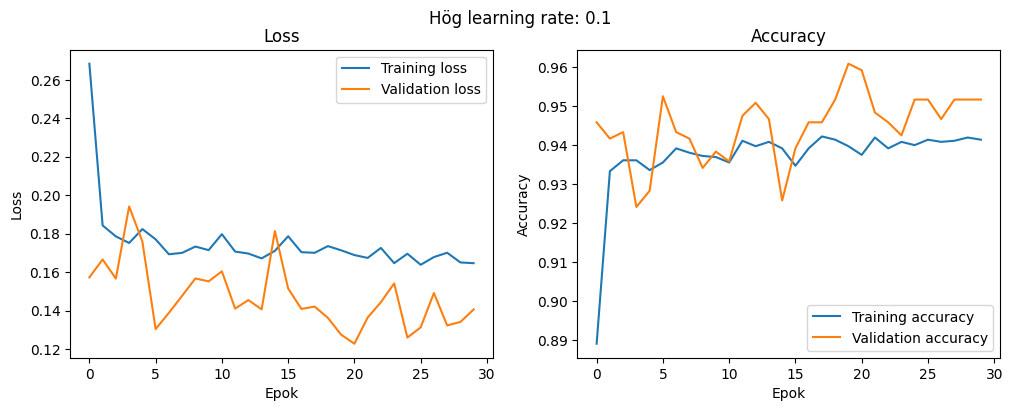

In [13]:
high_lr_model, high_lr_history, high_lr_result = run_experiment(
    name="Hög learning rate: 0.1",
    epochs=30,
    batch_size=32,
    learning_rate=0.1,
    verbose=0
)

results.append(high_lr_result)


Kör experiment: Låg batch size: 8
epochs=30, batch_size=8, learning_rate=0.001


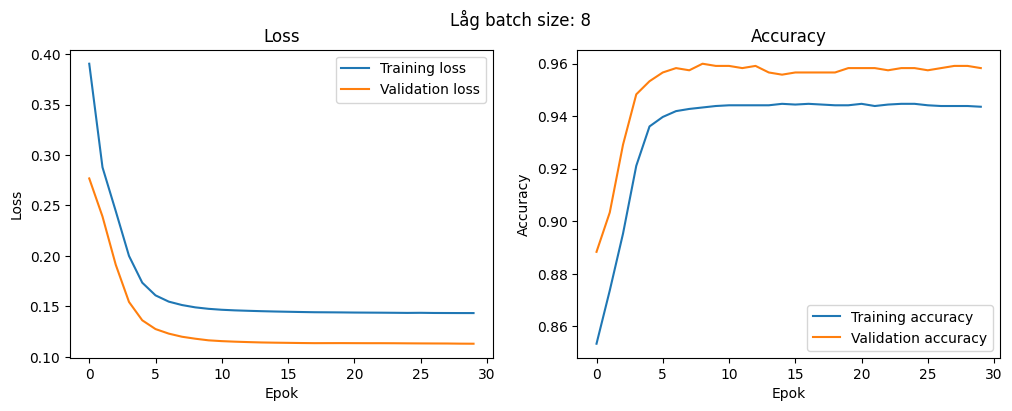

In [14]:
small_batch_model, small_batch_history, small_batch_result = run_experiment(
    name="Låg batch size: 8",
    epochs=30,
    batch_size=8,
    learning_rate=0.001,
    verbose=0
)

results.append(small_batch_result)


Kör experiment: Stor batch size: 512
epochs=30, batch_size=512, learning_rate=0.001


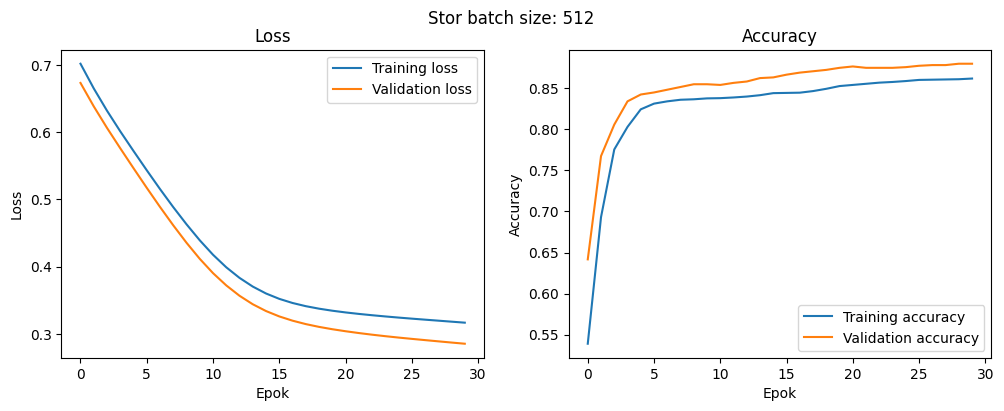

In [15]:
large_batch_model, large_batch_history, large_batch_result = run_experiment(
    name="Stor batch size: 512",
    epochs=30,
    batch_size=512,
    learning_rate=0.001,
    verbose=0
)

results.append(large_batch_result)

In [17]:
results_df = pd.DataFrame(results)

results_df.sort_values("test_accuraccy", ascending=False)

,experiment,epochs,batch_size,learning_rate,test_loss,test_accuraccy
2,Många epoker: 100 epoker,100,32,0.0010,0.178703,0.931667
0,"Baseline: 30 epoker, batch size 32, learning r...",30,32,0.0010,0.177950,0.930833
5,Låg batch size: 8,30,8,0.0010,0.180995,0.925833
4,Hög learning rate: 0.1,30,32,0.1000,0.215663,0.925000
1,Få epoker: 5 epoker,5,32,0.0010,0.287108,0.885833
3,Låg learning rate: 0.0001,30,32,0.0001,0.299862,0.880000
6,Stor batch size: 512,30,512,0.0010,0.305473,0.873333


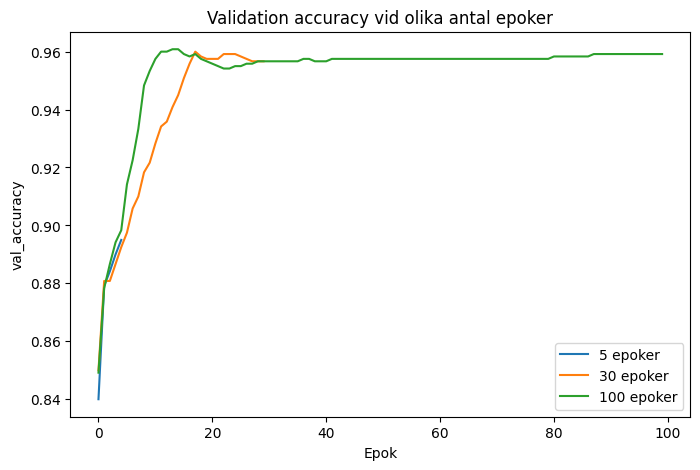

In [21]:
def plot_multiple_histories(histories, labels, metric="val_accuracy", title="Jämförelse"):
    """
    Plottar samma metric från flera träningshistoriker i samma graf.

    histories:
        Lista med history-objekt från model.fit().

    labels:
        Namn på experimenten. måste ha samma längd som histories.

    metric:
    Vilket värde från history.history som ska plottas.
    Exempel: "val_accuracy", "val_loss", "accuracy", "loss"  
    """

    plt.figure(figsize=(8, 5))

    for history, label in zip(histories, labels):
        plt.plot(history.history[metric], label=label)

    plt.xlabel("Epok")
    plt.ylabel(metric)
    plt.title(title)
    plt.legend()
    plt.show()


plot_multiple_histories(
    histories=[few_epochs_history, baseline_history, many_epochs_history],
    labels=["5 epoker", "30 epoker", "100 epoker"],
    metric="val_accuracy",
    title="Validation accuracy vid olika antal epoker"
)

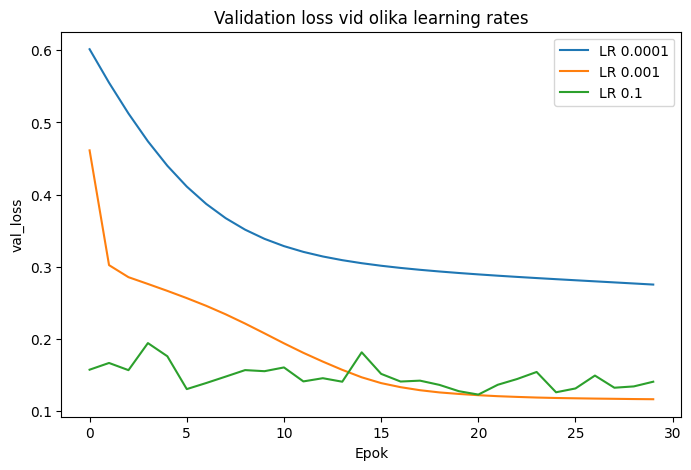

In [22]:
plot_multiple_histories(
    histories=[low_lr_history, baseline_history, high_lr_history],
    labels=["LR 0.0001", "LR 0.001", "LR 0.1"],
    metric="val_loss",
    title="Validation loss vid olika learning rates"
)

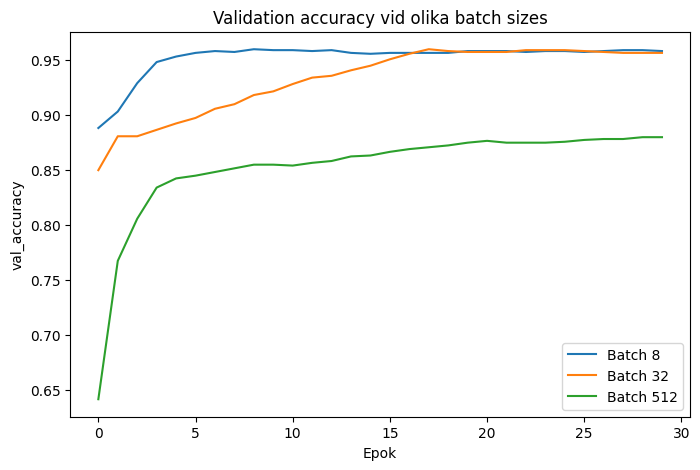

In [23]:
plot_multiple_histories(
    histories=[small_batch_history, baseline_history, large_batch_history],
    labels=["Batch 8", "Batch 32", "Batch 512"],
    metric="val_accuracy",
    title="Validation accuracy vid olika batch sizes"
)

In [24]:
chosen_model = baseline_model

y_pred_proba = chosen_model.predict(X_test_scaled)
y_pred = (y_pred_proba >= 0.5).astype(int).ravel()

test_accuracy = accuracy_score(y_test, y_pred)

print("Accuracy på testdata:", test_accuracy)

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 844us/step
Accuracy på testdata: 0.9308333333333333
